# Taxonomy / Topic Clustering Pipeline — Component Demo

Example notebook แสดง component หลักของ taxonomy/clustering pipeline (อ้างอิงจาก `old-concept-code/`):

1. **Input** — `list[str]`
2. **Chunking** — split ข้อความก่อน embed ด้วย `llama-index` `SentenceSplitter`
3. **Embedding** — `BAAI/bge-m3` (sentence-transformers) พร้อม prompt สำหรับจัดหมวดหมู่
4. **Dimensionality reduction** — เลือก UMAP parameters ที่เหมาะสมด้วย grid search แล้ว reduce เหลือ 2 มิติ (`coordinate_xy`)
5. **Clustering** — `KDEWatershedClusterer` (KDE + watershed segmentation) บน `coordinate_xy`
6. **Cluster naming** — ตั้งชื่อกลุ่มด้วย LLM ผ่าน `dspy`

Flow: `texts` → `chunks` (split) → `vectors` (embed) → `coordinate_xy` (UMAP) → `labels` (cluster) → `cluster_name`. Embed เกิดขึ้น **ครั้งเดียว** บน `chunks` — ไม่ embed `texts` ต้นฉบับซ้ำ

แต่ละ section รันแยกอิสระได้ ปรับ parameter/prompt ตามชุดข้อมูลจริงของคุณ

In [1]:
# %pip install -q sentence-transformers umap-learn scikit-learn scikit-image scipy pandas numpy matplotlib tqdm dspy-ai llama-index-core pythainlp

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"
np.random.seed(42)
import matplotlib.font_manager as fm

_THAI_FONT_CANDIDATES = [
    "Noto Sans Thai", "TH Sarabun New", "Sarabun", "Waree", "Loma", "Garuda",
    "Kinnari", "Norasi", "Sawasdee", "Tlwg Typist", "Tlwg Typo", "Tahoma", "Arial Unicode MS",
]


def _set_thai_font():
    """กัน UserWarning: Glyph ... missing from font(s) DejaVu Sans ตอน plot ข้อความไทย"""
    available = {f.name for f in fm.fontManager.ttflist}
    for name in _THAI_FONT_CANDIDATES:
        if name in available:
            plt.rcParams["font.family"] = name
            print(f"ใช้ฟอนต์ไทย: {name}")
            return name
    print(
        "\u26a0\ufe0f ไม่พบฟอนต์ไทยในระบบ ตัวอักษรไทยในกราฟจะแสดงเป็นกล่องว่าง (missing glyph)\n"
        "ติดตั้งฟอนต์ก่อน เช่น: sudo apt install fonts-thai-tlwg  (หรือ fonts-noto-cjk / Noto Sans Thai)\n"
        "แล้วล้าง matplotlib font cache: rm -rf ~/.cache/matplotlib  ก่อนรัน notebook ใหม่"
    )
    return None


_set_thai_font()

ใช้ฟอนต์ไทย: Waree


'Waree'

## 1. Input — `list[str]`

Pipeline รับ input เป็น `list[str]` เท่านั้น ตัวอย่างด้านล่างใช้ข้อความเหตุการณ์/ปัญหาภาษาไทยสั้น ๆ แทน sample data — แทนที่ด้วยข้อมูลจริงของคุณ (เช่นโหลดจาก CSV/Parquet แล้ว `.tolist()`)

In [3]:
# ตัวอย่าง: โหลดจากไฟล์จริง
df = pd.read_csv("./gem.csv")
texts: list[str] = df["content"].dropna().astype(str).tolist()
print(f"n = {len(texts)}")
texts[:3]

n = 71


['ตลาดเพชรธรรมชาติฮ่องกงเติบโตคึกคัก ด้วยสาเหตุจากความนิยมในการซื้อเพื่อมอบเป็นของขวัญ       ผลการศึกษาชี้ยอดขายพุ่งสูงอย่างมากในช่วงวันวาเลนไทน์ เทศกาลคริสต์มาส และการซื้อเพื่อนำไปใช้ในการหมั้น ตลาดเพชรธรรมชาติในฮ่องกงมีแนวโน้มขยายตัวอย่างต่อเนื่อง อันเป็นผลมาจากความต้องการซื้อเพื่อเป็นของขวัญที่เพิ่มสูงขึ้น รวมถึงปัจจัยอื่นๆ ตามผลการสำรวจที่จัดทำโดย\nNielsenIQ\nสหพันธ์เพชรฮ่องกง (\nDiamond Federation of Hong Kong: DFHK)\nและกลุ่มบริษัท\nDe Beers\nซึ่งเผยแพร่ในรายงานการสำรวจการค้าขายเพชรธรรมชาติฮ่องกง ประจำปี 2025\nเทศกาลสำคัญที่ส่งผลต่อยอดขายมากที่สุด ได้แก่ วันวาเลนไทน์ การหมั้นและงานแต่งงาน และเทศกาลคริสต์มาส โดยคิดเป็นสัดส่วนความต้องการที่ร้อยละ 69\n,\nร้อยละ 67 และร้อยละ 59 ตามลำดับ การสำรวจดังกล่าวจัดทำขึ้นในช่วงเดือนสิงหาคม โดยมีผู้ตอบแบบสอบถามจำนวน 200 ราย ซึ่งประกอบด้วยสมาชิกของ\nDFHK\nผู้ค้าปลีก ผู้ค้าส่ง และผู้ผลิตในอุตสาหกรรมเพชร ทั้งนี้เกือบครึ่งหนึ่งของผู้ตอบแบบสอบถามคาดการณ์ว่าตลาดเพชรธรรมชาติจะมีผลประกอบการที่ดีในช่วง 12 เดือนข้างหน้า ขณะที่ร้อยละ 33 คาดว่าตลาดจะมีเสถี

## 2. Chunking — `llama-index` (ก่อนเข้า embedding)

Split `texts` เป็น `chunks` ด้วย `SentenceSplitter` ของ `llama-index` (`llama-index-core`) ก่อน embed เพื่อไม่ให้เกิน context/embedding limit และให้แต่ละจุดใน embedding space สื่อความหมายเดียวชัดเจน

Sample texts ด้านบนสั้นอยู่แล้วจึงได้ 1 chunk/doc — สำหรับข้อความยาวจริงปรับ `CHUNK_SIZE`/`CHUNK_OVERLAP` ตามความเหมาะสม (หน่วยเป็น token) `chunk_doc_ids` เก็บ mapping กลับไปยัง index ของ `texts` ต้นฉบับ (เผื่อหลาย chunk มาจาก doc เดียวกัน)

**ขั้นตอนถัดไปทั้งหมด (embedding → UMAP → clustering → naming) ใช้ `chunks` เท่านั้น — ไม่ยุ่งกับ `texts` อีก**

In [4]:
from llama_index.core import Document
from llama_index.core.node_parser import SentenceSplitter

CHUNK_SIZE = 500
CHUNK_OVERLAP = 20

splitter = SentenceSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
documents = [Document(text=t, id_=str(i)) for i, t in enumerate(texts)]
nodes = splitter.get_nodes_from_documents(documents)

chunks: list[str] = [n.get_content() for n in nodes]
chunk_doc_ids: list[int] = [int(n.ref_doc_id) for n in nodes]

print(f"{len(texts)} docs -> {len(chunks)} chunks")
chunks[:3]

71 docs -> 857 chunks


['ตลาดเพชรธรรมชาติฮ่องกงเติบโตคึกคัก ด้วยสาเหตุจากความนิยมในการซื้อเพื่อมอบเป็นของขวัญ       ผลการศึกษาชี้ยอดขายพุ่งสูงอย่างมากในช่วงวันวาเลนไทน์ เทศกาลคริสต์มาส และการซื้อเพื่อนำไปใช้ในการหมั้น ตลาดเพชรธรรมชาติในฮ่องกงมีแนวโน้มขยายตัวอย่างต่อเนื่อง อันเป็นผลมาจากความต้องการซื้อเพื่อเป็นของขวัญที่เพิ่มสูงขึ้น รวมถึงปัจจัยอื่นๆ ตามผลการสำรวจที่จัดทำโดย\nNielsenIQ\nสหพันธ์เพชรฮ่องกง (\nDiamond Federation of Hong Kong: DFHK)\nและกลุ่มบริษัท\nDe Beers\nซึ่งเผยแพร่ในรายงานการสำรวจการค้าขายเพชรธรรมชาติฮ่องกง ประจำปี',
 'ประจำปี 2025\nเทศกาลสำคัญที่ส่งผลต่อยอดขายมากที่สุด ได้แก่ วันวาเลนไทน์ การหมั้นและงานแต่งงาน และเทศกาลคริสต์มาส โดยคิดเป็นสัดส่วนความต้องการที่ร้อยละ 69\n,\nร้อยละ 67 และร้อยละ 59 ตามลำดับ การสำรวจดังกล่าวจัดทำขึ้นในช่วงเดือนสิงหาคม โดยมีผู้ตอบแบบสอบถามจำนวน 200 ราย ซึ่งประกอบด้วยสมาชิกของ\nDFHK\nผู้ค้าปลีก ผู้ค้าส่ง และผู้ผลิตในอุตสาหกรรมเพชร ทั้งนี้เกือบครึ่งหนึ่งของผู้ตอบแบบสอบถามคาดการณ์ว่าตลาดเพชรธรรมชาติจะมีผลประกอบการที่ดีในช่วง 12 เดือนข้างหน้า ขณะที่ร้อยละ 33 คาดว่า

## 3. Embedding — `BAAI/bge-m3`

ใช้ `sentence-transformers` โหลด `BAAI/bge-m3` แล้ว encode `chunks` เป็น vector พร้อม instruction prompt ที่ชี้นำโมเดลว่าจะ embed เพื่อจุดประสงค์ใด (จัดหมวดหมู่ตามประเภทของปัญหา/ภัยพิบัติ)

**`EMBED_PROMPT` ปรับได้อิสระตามโดเมนข้อมูลของคุณ** — ตัวอย่างด้านล่างคือ prompt เริ่มต้น

In [5]:
import torch
from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = "BAAI/bge-m3"

# --- ผู้ใช้ปรับ prompt ตรงนี้ได้อิสระ ---
EMBED_PROMPT = "จงพิจารณาข้อความนี้เพื่อจัดหมวดหมู่ตามประเภทของอัญมณี และ อื่น ๆ"

# ปรับ EMBED_DEVICE ได้ตรง ๆ ("cuda", "cuda:0", "cpu") ถ้าไม่ตั้งจะ auto-detect + fallback เป็น cpu
# ให้เองถ้าโหลดขึ้น GPU แล้วเจอ error ระดับ kernel (เช่น GPU รุ่นเก่าที่ torch build ปัจจุบันไม่รองรับ
# เช่น "CUDA error: no kernel image is available for execution on the device")
EMBED_DEVICE = os.environ.get("EMBED_DEVICE")

if EMBED_DEVICE is None:
    EMBED_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

try:
    embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=EMBED_DEVICE)
    if EMBED_DEVICE.startswith("cuda"):
        # sanity check: ยิง forward เล็ก ๆ ให้ error (ถ้ามี) โผล่ตรงนี้ ไม่ใช่กลางลูป embed_texts
        embed_model.encode(["ทดสอบ"], show_progress_bar=False)
except RuntimeError as e:
    print(f"⚠️ โหลดโมเดลบน {EMBED_DEVICE} ไม่สำเร็จ ({e}) — fallback ไปใช้ cpu แทน")
    EMBED_DEVICE = "cpu"
    embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=EMBED_DEVICE)

print("embed device:", EMBED_DEVICE)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

/home/titan/miniconda3/envs/taxonomy/lib/python3.12/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU0 NVIDIA TITAN Xp which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.14.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/titan/miniconda3/envs/taxonomy/lib/python3.12/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU1 NVIDIA

⚠️ โหลดโมเดลบน cuda ไม่สำเร็จ (CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
) — fallback ไปใช้ cpu แทน


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

embed device: cpu


In [6]:
def embed_texts(
    texts: list[str],
    model: SentenceTransformer,
    prompt: str,
    batch_size: int = 32,
) -> np.ndarray:
    all_vectors = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch = texts[i : i + batch_size]
        vectors = model.encode(
            batch,
            prompt=prompt,
            normalize_embeddings=True,
            show_progress_bar=False,
        )
        all_vectors.extend(vectors)
    return np.array(all_vectors)


vectors = embed_texts(chunks, embed_model, EMBED_PROMPT)
print("Embedding shape:", vectors.shape)

Embedding: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [06:09<00:00, 13.68s/it]

Embedding shape: (857, 1024)


## 4. UMAP parameter selection → `coordinate_xy`

Grid search หา `n_neighbors` / `min_dist` ที่เหมาะสม อิงตาม `UmapClustering._parallel_worker_func` ใน `old-concept-code/main.py`: รันแต่ละชุด parameter ผ่าน UMAP แล้วประเมินด้วย quick clustering (KDE + watershed, section 5) รวม 3 metric เข้าด้วยกัน:

- `silhouette_score` (ยิ่งสูงยิ่งดี — จุดในกลุ่มเดียวกันอยู่ใกล้กัน กลุ่มต่างกันอยู่ห่างกัน)
- `davies_bouldin_score` (ยิ่งต่ำยิ่งดี — ลบออกจาก score)
- `entropy` ของ KDE density histogram (ยิ่งสูงยิ่งดี — ความหนาแน่นกระจายเป็นหลายยอดชัดเจน ไม่ใช่ก้อนเดียวหรือแบนราบไร้โครงสร้าง)

`ranking_score = entropy + silhouette - davies_bouldin` — ใช้จัดอันดับหา parameter ที่ดีที่สุด (เหมือน `ranking_score` ใน `_parallel_worker_func`)

**ต้องรัน cell ของ `KDEWatershedClusterer` (section 5) ก่อน** เพราะใช้ประเมินคุณภาพแต่ละชุด UMAP parameter

In [7]:
import numpy as np
from scipy.stats import gaussian_kde
from scipy.ndimage import maximum_filter
from skimage.segmentation import watershed


class KDEWatershedClusterer:
    """KDE density + watershed segmentation clusterer, with boundary/bridge point detection.

    อ้างอิงจาก old-concept-code/clustering.py + docs/hierarchical-taxonomy-concept.md (section 11)
    """

    def __init__(
        self,
        bw_method=0.1,
        grid_size=100,
        neighborhood_size=5,
        rel_threshold=None,
        bridge_window=3,
        bridge_rel_threshold=None,
    ):
        self.bw_method = bw_method
        self.grid_size = grid_size
        self.neighborhood_size = neighborhood_size
        self.rel_threshold = rel_threshold if rel_threshold is not None else self.bw_method
        self.bridge_window = bridge_window                  # ขนาดหน้าต่าง (NxN) เช็ค label รอบจุด หา basin ข้างเคียง
        self.bridge_rel_threshold = bridge_rel_threshold    # None = ปิด density-ratio check (ใช้แค่ label diversity)
        self.embedding_, self.kde_dict_, self.peaks_, self.cluster_centers_, self.labels_ = [None] * 5
        self.bridge_between_ = {}  # point index -> sorted list ของ cluster id ที่จุดนั้นอยู่ระหว่างกลาง

    def fit_predict(self, X):
        self.embedding_ = X
        x, y = X[:, 0], X[:, 1]
        self.kde_dict_ = self._calculate_kde(x, y)
        self.peaks_ = self._find_peaks()
        if self.peaks_:
            self.cluster_centers_ = np.array([[p["x"], p["y"]] for p in self.peaks_])
        else:
            self.cluster_centers_ = np.empty((0, 2))
        self.labels_ = self._assign_labels_by_watershed(X)
        return self.labels_

    def get_results_dict(self):
        if self.labels_ is None:
            raise RuntimeError("ต้องรัน .fit_predict(X) ก่อน")
        centers_dict = {str(i): c.tolist() for i, c in enumerate(self.cluster_centers_)}
        serializable_kde = {k: v.tolist() if isinstance(v, np.ndarray) else v for k, v in self.kde_dict_.items()}
        return {
            "labels": self.labels_.tolist(),
            "centers": centers_dict,
            "kde_dict": serializable_kde,
            "xy": self.embedding_.tolist(),
            "bridge_between": {str(k): v for k, v in self.bridge_between_.items()},
        }

    def _calculate_kde(self, x, y):
        kde = gaussian_kde(np.vstack([x, y]), bw_method=self.bw_method)
        xmin, xmax, ymin, ymax = x.min() - 1, x.max() + 1, y.min() - 1, y.max() + 1
        x_grid, y_grid = np.meshgrid(np.linspace(xmin, xmax, self.grid_size), np.linspace(ymin, ymax, self.grid_size))
        kde_values = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
        return {"x_grid": x_grid, "y_grid": y_grid, "kde_values": kde_values, "bw_method": self.bw_method}

    def _find_peaks(self):
        vals = self.kde_dict_["kde_values"]
        mask = (vals == maximum_filter(vals, size=self.neighborhood_size)) & (vals > vals.max() * self.rel_threshold)
        rows, cols = np.where(mask)
        if len(rows) == 0:
            return []
        return [{"x": self.kde_dict_["x_grid"][r, c], "y": self.kde_dict_["y_grid"][r, c]} for r, c in zip(rows, cols)]

    def _assign_labels_by_watershed(self, xy):
        self.bridge_between_ = {}
        if not self.peaks_:
            return np.full(xy.shape[0], -1)

        kde_values = self.kde_dict_["kde_values"]
        xmin, xmax = self.kde_dict_["x_grid"][0, 0], self.kde_dict_["x_grid"][0, -1]
        ymin, ymax = self.kde_dict_["y_grid"][0, 0], self.kde_dict_["y_grid"][-1, 0]

        markers_grid = np.zeros_like(kde_values, dtype=int)
        for i, peak in enumerate(self.peaks_):
            r = np.abs(self.kde_dict_["y_grid"][:, 0] - peak["y"]).argmin()
            c = np.abs(self.kde_dict_["x_grid"][0, :] - peak["x"]).argmin()
            markers_grid[r, c] = i + 1

        # watershed_line=True: สันเขา (ridge) ระหว่าง basin ได้ label 0 แยกออกมา
        # แทนที่จะยัดทุก grid cell เข้า basin ใดบาสินหนึ่งเสมอเหมือนเดิม (ดู docs section 11)
        labels_grid = watershed(-kde_values, markers_grid, mask=np.ones_like(kde_values, dtype=bool), watershed_line=True)

        cols = np.clip(((xy[:, 0] - xmin) / (xmax - xmin) * (self.grid_size - 1)).astype(int), 0, self.grid_size - 1)
        rows = np.clip(((xy[:, 1] - ymin) / (ymax - ymin) * (self.grid_size - 1)).astype(int), 0, self.grid_size - 1)

        half_w = self.bridge_window // 2
        labels = np.full(xy.shape[0], -1)

        for idx, (r, c) in enumerate(zip(rows, cols)):
            r0, r1 = max(0, r - half_w), min(self.grid_size, r + half_w + 1)
            c0, c1 = max(0, c - half_w), min(self.grid_size, c + half_w + 1)
            window = labels_grid[r0:r1, c0:c1]
            neighbor_ids = sorted(int(v) for v in np.unique(window) if v > 0)  # ตัด 0 (ridge) ทิ้ง เหลือแต่ basin จริง

            if len(neighbor_ids) == 0:
                labels[idx] = -1  # ไม่มี basin ให้ยึดเลยแม้แต่ในหน้าต่างรอบตัว (rare)
            elif len(neighbor_ids) == 1:
                labels[idx] = neighbor_ids[0] - 1  # อยู่แน่นอนใน basin เดียว -> cluster ปกติ
            else:
                # เจอมากกว่า 1 basin ในหน้าต่างรอบจุด -> ผู้สมัคร bridge point
                cluster_ids = [n - 1 for n in neighbor_ids]
                peak_densities = {}
                for cid in cluster_ids:
                    peak = self.peaks_[cid]
                    rr = np.abs(self.kde_dict_["y_grid"][:, 0] - peak["y"]).argmin()
                    cc = np.abs(self.kde_dict_["x_grid"][0, :] - peak["x"]).argmin()
                    peak_densities[cid] = kde_values[rr, cc]

                if self.bridge_rel_threshold is not None:
                    # density-ratio เสริม: ถ้าความหนาแน่น ณ จุดนี้ยังสูงพอเทียบกับยอดที่เด่นสุดในหน้าต่าง
                    # (แค่ติดขอบ grid ไม่ได้อยู่ก้นแอ่งจริง) ให้ fallback เข้ากลุ่มนั้นแทนการเป็น bridge
                    point_density = kde_values[r, c]
                    best_cid = max(peak_densities, key=peak_densities.get)
                    if point_density >= self.bridge_rel_threshold * peak_densities[best_cid]:
                        labels[idx] = best_cid
                        continue

                labels[idx] = -2
                self.bridge_between_[idx] = cluster_ids

        return labels

In [8]:
import umap
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import silhouette_score, davies_bouldin_score

# --- grid search space: ปรับตามขนาด/ความหนาแน่นของข้อมูลจริง ---
UMAP_SEARCH_SPACE = {
    "n_neighbors": [5, 10, 15],
    "min_dist": [0.1, 0.3],
}
PROBE_BW = 0.15          # bandwidth ใช้แค่สำหรับ "ประเมิน" คุณภาพแต่ละชุด UMAP param
PROBE_GRID_SIZE = 100
PROBE_NEIGHBORHOOD = 5


def _kde_entropy(kde_values: np.ndarray, bins: int = 1000) -> float:
    """เหมือน _get_entropy_for_worker ใน old-concept-code/main.py"""
    hist, _ = np.histogram(kde_values.flatten(), bins=bins, density=True)
    return scipy_entropy(hist)


param_list = [
    {"n_neighbors": n, "min_dist": d}
    for n in UMAP_SEARCH_SPACE["n_neighbors"]
    for d in UMAP_SEARCH_SPACE["min_dist"]
]

# เก็บ xy / kde_dict / centers ของทุก run ไว้ด้วย ใช้ทั้งจัดอันดับและ plot เปรียบเทียบ top-N ด้านล่าง
# (สำหรับ dataset ใหญ่ ใน main.py ใช้ joblib.Parallel รัน param_list พร้อมกันหลาย core แทน loop ตรง ๆ)
ranking = []
for params in tqdm(param_list, desc="UMAP grid search"):
    reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42, **params)
    xy_probe = reducer.fit_transform(vectors)

    probe_clusterer = KDEWatershedClusterer(
        bw_method=PROBE_BW, grid_size=PROBE_GRID_SIZE, neighborhood_size=PROBE_NEIGHBORHOOD
    )
    probe_labels = probe_clusterer.fit_predict(xy_probe)

    core_mask = probe_labels >= 0  # กัน -1 (noise) และ -2 (bridge) ไม่ให้ถูกนับเป็น "cluster จริง" ตอนให้คะแนน
    if core_mask.sum() > 1 and len(np.unique(probe_labels[core_mask])) > 1:
        sil = silhouette_score(xy_probe[core_mask], probe_labels[core_mask])
        db = davies_bouldin_score(xy_probe[core_mask], probe_labels[core_mask])
    else:
        sil, db = -1.0, float("inf")

    entp = _kde_entropy(probe_clusterer.kde_dict_["kde_values"])
    score = entp + sil - db

    ranking.append({
        **params,
        "silhouette": sil,
        "davies_bouldin": db,
        "entropy": entp,
        "score": score,
        "xy": xy_probe,
        "kde_dict": probe_clusterer.kde_dict_,
        "centers": probe_clusterer.cluster_centers_,
    })

ranking.sort(key=lambda r: r["score"], reverse=True)

ranking_df = pd.DataFrame([
    {k: r[k] for k in ("n_neighbors", "min_dist", "silhouette", "davies_bouldin", "entropy", "score")}
    for r in ranking
])
ranking_df

UMAP grid search:   0%|                                                                                                                          | 0/6 [00:00<?, ?it/s]/home/titan/miniconda3/envs/taxonomy/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP grid search:  17%|███████████████████                                                                                               | 1/6 [00:10<00:54, 10.83s/it]/home/titan/miniconda3/envs/taxonomy/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP grid search:  33%|██████████████████████████████████████                                                                            | 2/6 [00:12<00:21,  5.49s/it]/home/titan/miniconda3/envs/taxonomy/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 o

,n_neighbors,min_dist,silhouette,davies_bouldin,entropy,score
0,15,0.3,0.453980,0.591164,4.920394,4.783210
1,10,0.1,0.511624,0.551161,4.713144,4.673607
2,10,0.3,0.434112,0.614807,4.580888,4.400193
3,15,0.1,0.520620,0.612728,4.190287,4.098179
4,5,0.1,0.530224,0.546978,3.179860,3.163106
5,5,0.3,0.448478,0.555835,2.980915,2.873559


### เปรียบเทียบ candidate อันดับต้น ๆ (visual)

Score สูงสุดไม่ได้แปลว่าดีที่สุดเสมอไปในทางปฏิบัติ — plot contour (density) + scatter ของ top-N candidate เทียบกัน (เหมือน `show_top_n_ranking_plots` ใน `main.py`) เพื่อ eyeball ประกอบการตัดสินใจก่อนเลือก `best_params`

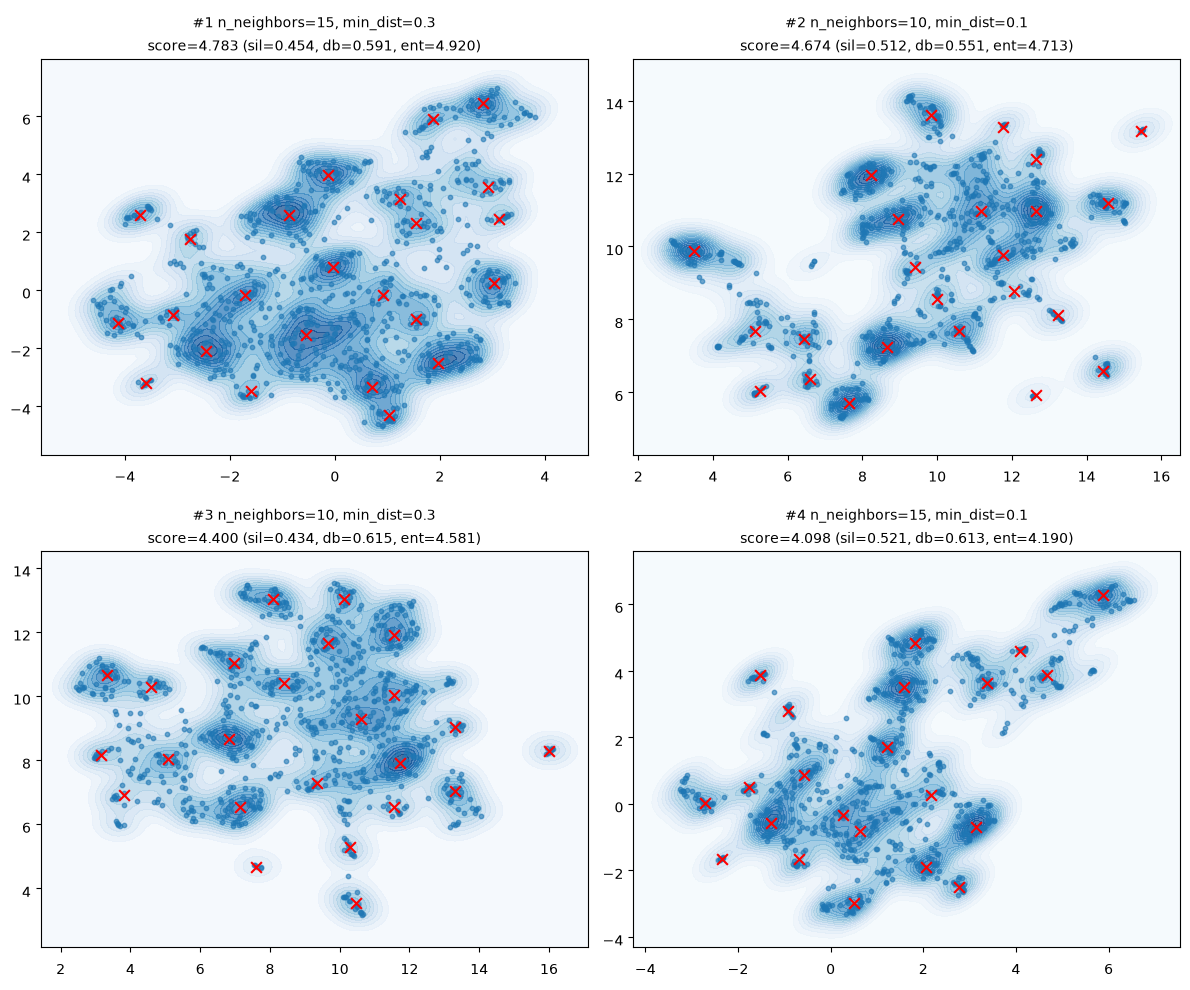

In [9]:
TOP_N = min(4, len(ranking))
n_cols = 2
n_rows = (TOP_N + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 5), squeeze=False)
axes_flat = axes.flatten()

for i in range(TOP_N):
    r = ranking[i]
    ax = axes_flat[i]
    ax.contourf(r["kde_dict"]["x_grid"], r["kde_dict"]["y_grid"], r["kde_dict"]["kde_values"], levels=20, cmap="Blues", alpha=0.7)
    ax.scatter(r["xy"][:, 0], r["xy"][:, 1], s=10, alpha=0.6)
    if r["centers"].size > 0:
        ax.scatter(r["centers"][:, 0], r["centers"][:, 1], marker="x", s=60, c="red", zorder=10)
    ax.set_title(
        f"#{i+1} n_neighbors={r['n_neighbors']}, min_dist={r['min_dist']}\n"
        f"score={r['score']:.3f} (sil={r['silhouette']:.3f}, db={r['davies_bouldin']:.3f}, ent={r['entropy']:.3f})",
        fontsize=10,
    )
for i in range(TOP_N, len(axes_flat)):
    axes_flat[i].set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
best = ranking[0]
best_params = {"n_neighbors": int(best["n_neighbors"]), "min_dist": float(best["min_dist"])}
print("Best UMAP params:", best_params, "| score:", round(best["score"], 4))

# reuse embedding ที่ได้ตอน grid search ตรง ๆ (เหมือน best_embedding ใน UmapClustering.fit) — ไม่ fit ซ้ำ
coordinate_xy = best["xy"]

# fit เก็บ UMAP model object ไว้ด้วย เผื่อต้อง .transform() ข้อมูลใหม่ภายหลัง (เหมือน best_umap_model_ ใน main.py)
best_umap_model = umap.UMAP(n_components=2, metric="cosine", random_state=42, **best_params).fit(vectors)

print("coordinate_xy shape:", coordinate_xy.shape)

Best UMAP params: {'n_neighbors': 15, 'min_dist': 0.3} | score: 4.7832


/home/titan/miniconda3/envs/taxonomy/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


coordinate_xy shape: (857, 2)


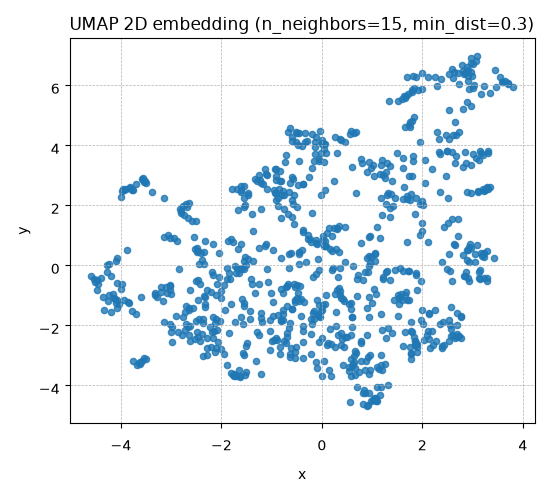

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(coordinate_xy[:, 0], coordinate_xy[:, 1], s=20, alpha=0.8)
plt.title(f"UMAP 2D embedding (n_neighbors={best_params['n_neighbors']}, min_dist={best_params['min_dist']})")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

## 5. Clustering — `KDEWatershedClusterer`

รัน clusterer จริง (คนละ instance จากตอน grid search) บน `coordinate_xy` ที่เลือกแล้ว — ปรับ `bw_method` (bandwidth) ให้เหมาะสมกับความหนาแน่น/จำนวนกลุ่มที่ต้องการ: bandwidth เล็ก → กลุ่มย่อยเยอะ, bandwidth ใหญ่ → กลุ่มใหญ่รวมกัน

**Boundary/Bridge point** — จุดที่อยู่ระหว่างยอดเขา (peak) ตั้งแต่ 2 ยอดขึ้นไป (หุบเขา/แอ่งน้ำระหว่างกลาง) จะไม่ถูกยัดเข้ากลุ่มไหนอีกต่อไป ได้ `cluster_id = -2` แทน พร้อม `bridge_between` บอกว่าอยู่ระหว่างกลุ่มไหนบ้าง (แยกจาก `cluster_id = -1` ที่แปลว่าทั้ง dataset ไม่มี peak เลย) ปรับความไวได้ด้วย `bridge_window` (ขนาดหน้าต่างเช็ค label รอบจุด) และ `bridge_rel_threshold` (ทางเลือก — เสริม density-ratio กันจับ bridge ไวเกินไป) ดูรายละเอียดที่ `docs/hierarchical-taxonomy-concept.md` section 11

In [12]:
CLUSTER_BW = 0.15
CLUSTER_GRID_SIZE = 120
CLUSTER_NEIGHBORHOOD = 7
BRIDGE_WINDOW = 3            # ขนาดหน้าต่าง (NxN) เช็คว่าจุดอยู่ใกล้มากกว่า 1 basin หรือไม่
BRIDGE_REL_THRESHOLD = None  # ตั้งเป็นตัวเลข (เช่น 0.5) เพื่อเปิด density-ratio check เสริม

clusterer = KDEWatershedClusterer(
    bw_method=CLUSTER_BW,
    grid_size=CLUSTER_GRID_SIZE,
    neighborhood_size=CLUSTER_NEIGHBORHOOD,
    bridge_window=BRIDGE_WINDOW,
    bridge_rel_threshold=BRIDGE_REL_THRESHOLD,
)
labels = clusterer.fit_predict(coordinate_xy)

result_df = pd.DataFrame({
    "text": chunks,
    "doc_id": chunk_doc_ids,
    "x": coordinate_xy[:, 0],
    "y": coordinate_xy[:, 1],
    "cluster_id": labels,
})
result_df["bridge_between"] = [clusterer.bridge_between_.get(i) for i in range(len(result_df))]

n_clusters = len([c for c in result_df["cluster_id"].unique() if c >= 0])
n_bridge = int((result_df["cluster_id"] == -2).sum())
n_noise = int((result_df["cluster_id"] == -1).sum())
print(f"n clusters: {n_clusters} | bridge points: {n_bridge} | noise (no peak): {n_noise}")
result_df.head()

n clusters: 24 | bridge points: 58 | noise (no peak): 0


,text,doc_id,x,y,cluster_id,bridge_between
0,ตลาดเพชรธรรมชาติฮ่องกงเติบโตคึกคัก ด้วยสาเหตุจ...,0,-1.929170,-1.489899,5,None
1,ประจำปี 2025\nเทศกาลสำคัญที่ส่งผลต่อยอดขายมากท...,0,0.183062,-3.709000,2,None
2,46 ของผู้ประกอบการมีแผนจะเพิ่มงบประมาณทางด้านก...,0,-1.428041,-1.544444,-2,"[5, 6]"
3,และการสื่อความหมายในการเลือกซื้อเครื่องประดับ\...,0,-2.280020,-0.815212,-2,"[5, 10]"
4,พร้อมใช้โซเชียลมีเดียและการรับรองคุณภาพเป็นเคร...,0,-2.002994,-0.863760,10,None


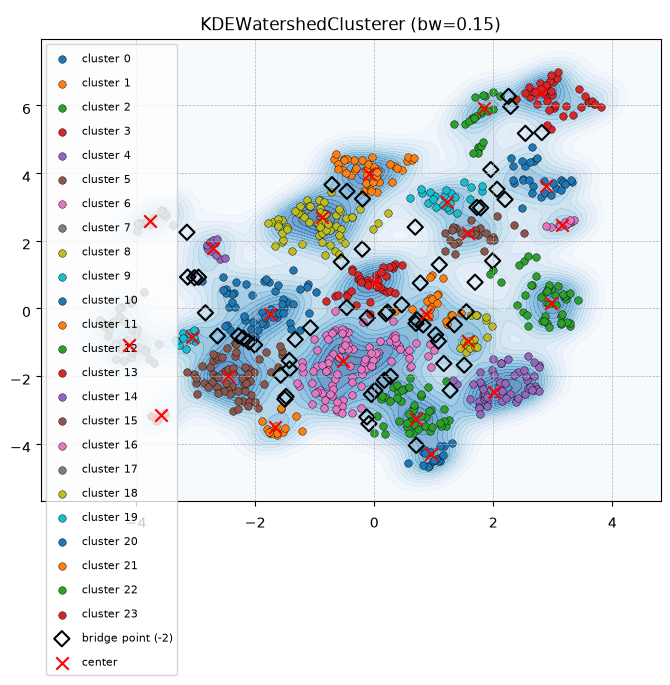

In [13]:
kde_dict = clusterer.kde_dict_
centers = clusterer.cluster_centers_

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(kde_dict["x_grid"], kde_dict["y_grid"], kde_dict["kde_values"], levels=20, cmap="Blues", alpha=0.6)
for cid in sorted(c for c in result_df["cluster_id"].unique() if c >= 0):
    pts = result_df[result_df["cluster_id"] == cid]
    ax.scatter(pts["x"], pts["y"], s=30, label=f"cluster {cid}", edgecolor="black", linewidth=0.3)
bridge_pts = result_df[result_df["cluster_id"] == -2]
if len(bridge_pts):
    ax.scatter(bridge_pts["x"], bridge_pts["y"], s=60, marker="D", facecolor="none", edgecolor="black", linewidth=1.5, label="bridge point (-2)")
if centers.size > 0:
    ax.scatter(centers[:, 0], centers[:, 1], marker="x", s=80, c="red", zorder=10, label="center")
ax.set_title(f"KDEWatershedClusterer (bw={CLUSTER_BW})")
ax.legend(loc="best", fontsize=8)
ax.grid(True, linestyle="--", linewidth=0.5)
plt.show()

## 6. Cluster naming — LLM ผ่าน `dspy`

สุ่มตัวอย่างข้อความในแต่ละ `cluster_id` แล้วให้ LLM (ผ่าน `dspy.Signature` + `dspy.Predict`) ตั้งชื่อหมวดหมู่

รองรับ 2 backend ผ่าน `LLM_BACKEND` (`os.environ["LLM_BACKEND"]`):

- `"openai"` (default) — ใช้ `DSPY_MODEL` (default `openai/gpt-4o-mini`) + `OPENAI_API_KEY`
- `"ollama"` — ใช้ `OLLAMA_MODEL` (default `gemma3:27b`) + `OLLAMA_HOST` (default `http://localhost:11434`) เหมือน pattern ollama ใน `02-clustering-edit.ipynb`

ก่อนตั้งชื่อจริงมี health check ยิง request เล็ก ๆ เช็คว่า LLM ใช้งานได้ — **ถ้า LLM ใช้ไม่ได้เลย หรือล้มเหลวระหว่างทางเป็นราย cluster จะ fallback ไปตั้งชื่อด้วย TF-IDF keyword แทนอัตโนมัติ** (ไม่ต้องพึ่ง LLM เลยก็ยังได้ชื่อ cluster ออกมา แม้จะสื่อความหมายได้หยาบกว่า)

In [14]:
import dspy

# --- เลือก backend: "openai" หรือ "ollama" ---
LLM_BACKEND = os.environ.get("LLM_BACKEND", "openai")  # "openai" | "ollama"

if LLM_BACKEND == "ollama":
    OLLAMA_MODEL = os.environ.get("OLLAMA_MODEL", "gemma3:27b")
    OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
    lm = dspy.LM(f"ollama_chat/{OLLAMA_MODEL}", api_base=OLLAMA_HOST, api_key="")
else:
    DSPY_MODEL = os.environ.get("DSPY_MODEL", "openai/gpt-4o-mini")
    lm = dspy.LM(DSPY_MODEL, api_key=os.environ.get("OPENAI_API_KEY"))

dspy.configure(lm=lm)


class TopicLabeler(dspy.Signature):
    """วิเคราะห์ข้อความตัวอย่างและตั้งชื่อหมวดหมู่ของปัญหา/ภัยพิบัติที่เกิดขึ้น เป็นภาษาไทยแบบสั้น กระชับ สื่อความหมายถึงภาพรวมของข้อความทั้งหมด"""

    samples = dspy.InputField(desc="รายการข้อความตัวอย่างที่อยู่ในกลุ่มเดียวกัน")
    taxonomy_name = dspy.OutputField(desc="ชื่อหมวดหมู่สั้น กระชับ เป็นภาษาไทย")


def llm_available() -> bool:
    """ยิง request เล็ก ๆ เช็คว่า LLM backend ที่เลือกใช้งานได้จริงก่อนรัน loop เต็ม"""
    try:
        dspy.Predict(TopicLabeler)(samples="- ทดสอบระบบ")
        return True
    except Exception as e:
        print(f"\u26a0\ufe0f LLM backend '{LLM_BACKEND}' \u0e43\u0e0a\u0e49\u0e07\u0e32\u0e19\u0e44\u0e21\u0e48\u0e44\u0e14\u0e49: {e}")
        return False


LLM_OK = llm_available()
print("LLM backend:", LLM_BACKEND, "| available:", LLM_OK)

⚠️ LLM backend 'openai' ใช้งานไม่ได้: [gpt-4o-mini] litellm.InternalServerError: InternalServerError: OpenAIException - Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_KEY` environment variable.
LLM backend: openai | available: False


In [15]:
# pip install pythainlp

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from pythainlp.corpus import thai_stopwords
from pythainlp.tokenize import word_tokenize

_THAI_STOPWORDS = thai_stopwords()


def _thai_tokenizer(text: str) -> list[str]:
    """sklearn default token_pattern (\w+) แตกคำไทยผิด เพราะสระ/วรรณยุกต์เป็น combining mark
    ไม่ match \w แยกกลางคำ (เช่น "ระดับน้ำ" -> "ระด", "บน", "ำ") ต้องใช้ตัวตัดคำไทยจริงแทน
    """
    tokens = word_tokenize(text, engine="newmm")
    return [t for t in tokens if t.strip() and len(t) > 1 and t not in _THAI_STOPWORDS and not t.isdigit()]


def _keyword_cluster_names(df: pd.DataFrame, text_col="text", cluster_col="cluster_id", top_n=3) -> dict[int, str]:
    """Fallback ตั้งชื่อ cluster ด้วย TF-IDF keyword (ไม่พึ่ง LLM)

    ต่างจาก _get_cluster_name_from_text (CountVectorizer ต่อ cluster เดียว) ใน old-concept-code/main.py
    ตรงนี้ fit TF-IDF ข้ามทุก cluster พร้อมกัน (1 cluster = 1 "document") ทำให้คำที่พบทั่วทุก cluster
    ถูกลดน้ำหนักลงจริง (idf) เหลือแต่คำที่เด่นเฉพาะ cluster นั้น ๆ
    """
    cluster_ids = sorted(c for c in df[cluster_col].unique() if c >= 0)
    corpus = [" ".join(df.loc[df[cluster_col] == cid, text_col]) for cid in cluster_ids]

    try:
        vectorizer = TfidfVectorizer(max_features=2000, tokenizer=_thai_tokenizer, token_pattern=None)
        tfidf = vectorizer.fit_transform(corpus)
        terms = vectorizer.get_feature_names_out()
    except ValueError:
        # corpus ว่าง/มีแต่ stopword ฯลฯ -> ไม่มีคำให้ดึง
        return {cid: f"cluster_{cid}" for cid in cluster_ids}

    names: dict[int, str] = {}
    for row_idx, cid in enumerate(cluster_ids):
        row = tfidf[row_idx].toarray().flatten()
        top_idx = row.argsort()[::-1][:top_n]
        top_terms = [terms[i] for i in top_idx if row[i] > 0]
        names[cid] = "-".join(top_terms) if top_terms else f"cluster_{cid}"
    return names


def name_clusters(df: pd.DataFrame, text_col="text", cluster_col="cluster_id", sample_size=15) -> dict[int, str]:
    cluster_ids = sorted(c for c in df[cluster_col].unique() if c >= 0)
    keyword_fallback = _keyword_cluster_names(df, text_col, cluster_col)

    if not LLM_OK:
        print("LLM \u0e43\u0e0a\u0e49\u0e44\u0e21\u0e48\u0e44\u0e14\u0e49 -> \u0e15\u0e31\u0e49\u0e07\u0e0a\u0e37\u0e48\u0e2d\u0e17\u0e38\u0e01 cluster \u0e14\u0e49\u0e27\u0e22 TF-IDF keyword \u0e41\u0e17\u0e19")
        return keyword_fallback

    predictor = dspy.Predict(TopicLabeler)
    names: dict[int, str] = {}

    for cid in cluster_ids:
        cluster_texts = df.loc[df[cluster_col] == cid, text_col]
        n = min(len(cluster_texts), sample_size)
        sample = cluster_texts.sample(n=n, random_state=42).tolist()
        samples_str = "\n".join(f"- {t}" for t in sample)

        try:
            pred = predictor(samples=samples_str)
            names[cid] = pred.taxonomy_name.strip(' "\'')
        except Exception as e:
            print(f"cluster {cid}: LLM \u0e25\u0e49\u0e21\u0e40\u0e2b\u0e25\u0e27 ({e}) -> \u0e43\u0e0a\u0e49 TF-IDF keyword \u0e41\u0e17\u0e19")
            names[cid] = keyword_fallback.get(cid, f"cluster_{cid}")

    return names


def _cluster_name_or_special(cid):
    if cid in cluster_names:
        return cluster_names[cid]
    if cid == -2:
        return "bridge"  # จุดเชื่อมระหว่างกลุ่ม ไม่ใช่ noise ธรรมดา (ดู docs section 10-11)
    return "noise"


cluster_names = name_clusters(result_df)
result_df["cluster_name"] = result_df["cluster_id"].map(_cluster_name_or_special)
cluster_names

<>:9: SyntaxWarning: invalid escape sequence '\w'
<>:9: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1505740/3510974710.py:9: SyntaxWarning: invalid escape sequence '\w'
  """sklearn default token_pattern (\w+) แตกคำไทยผิด เพราะสระ/วรรณยุกต์เป็น combining mark


LLM ใช้ไม่ได้ -> ตั้งชื่อทุก cluster ด้วย TF-IDF keyword แทน


{np.int64(0): 'ใช้จ่าย-วันแม่-เทศกาล',
 np.int64(1): 'สี-พลอย-ความนิยม',
 np.int64(2): 'เครื่องประดับ-สหรัฐฯ-ร้อยละ',
 np.int64(3): 'สมาร์ท-วอทช์-นาฬิกา',
 np.int64(4): 'ออสเตรเลีย-เครื่องประดับ-สินค้า',
 np.int64(5): 'จีน-เครื่องประดับ-ผู้บริโภค',
 np.int64(6): 'เครื่องประดับ-สินค้า-ผู้บริโภค',
 np.int64(7): 'ไข่มุก-มณฑล-จีน',
 np.int64(8): 'pandora-รีไซเคิล-สาขา',
 np.int64(9): 'kol-สด-(tiktok)',
 np.int64(10): 'งานแสดงสินค้า-งาน-สินค้า',
 np.int64(11): 'นาฬิกา-สินค้า-สหราชอาณาจักร',
 np.int64(12): 'เพชร-grown-lab',
 np.int64(13): 'สินค้า-เดนมาร์ก-ฟินแลนด์',
 np.int64(14): 'เมียนมา-memo-cash',
 np.int64(15): 'อินเดีย-lgd-เพชร',
 np.int64(16): 'สุ-รัต-เมือง',
 np.int64(17): 'บังกลาเทศ-คํา-ํา',
 np.int64(18): 'เหรียญ-นำเข้า-มูลค่า',
 np.int64(19): 'อินเดีย-ภาษีนำเข้า-ทองคำ',
 np.int64(20): 'อิรัก-เอ-ยู',
 np.int64(21): 'สหรัฐฯ-ภาษี-สินค้า',
 np.int64(22): 'อิสราเอล-อียิปต์-เดือน',
 np.int64(23): 'อิสราเอล-เพชร-diamond'}

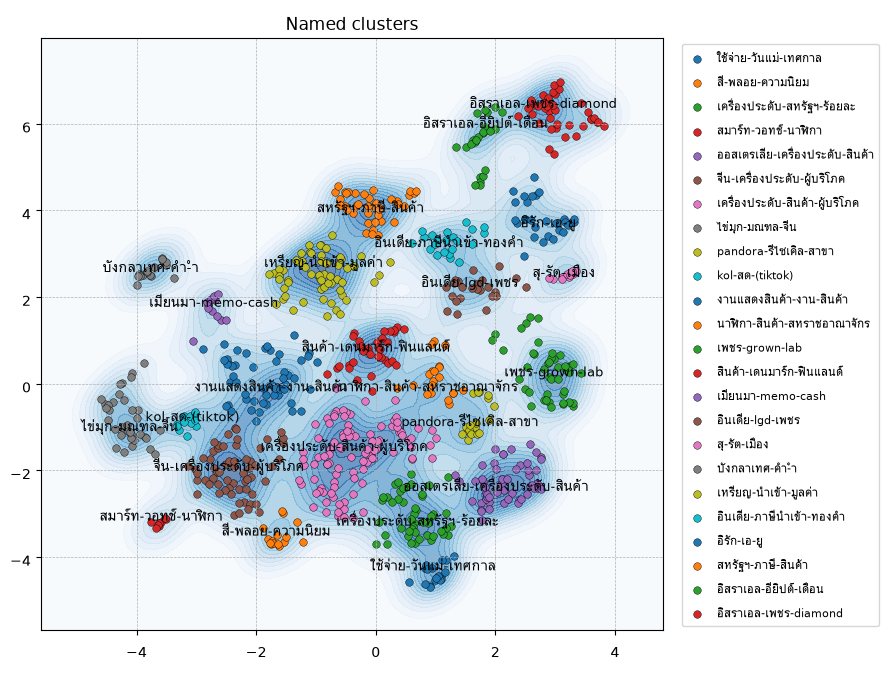

,text,doc_id,x,y,cluster_id,bridge_between,cluster_name
0,ตลาดเพชรธรรมชาติฮ่องกงเติบโตคึกคัก ด้วยสาเหตุจ...,0,-1.929170,-1.489899,5,None,จีน-เครื่องประดับ-ผู้บริโภค
1,ประจำปี 2025\nเทศกาลสำคัญที่ส่งผลต่อยอดขายมากท...,0,0.183062,-3.709000,2,None,เครื่องประดับ-สหรัฐฯ-ร้อยละ
2,46 ของผู้ประกอบการมีแผนจะเพิ่มงบประมาณทางด้านก...,0,-1.428041,-1.544444,-2,"[5, 6]",bridge
3,และการสื่อความหมายในการเลือกซื้อเครื่องประดับ\...,0,-2.280020,-0.815212,-2,"[5, 10]",bridge
4,พร้อมใช้โซเชียลมีเดียและการรับรองคุณภาพเป็นเคร...,0,-2.002994,-0.863760,10,None,งานแสดงสินค้า-งาน-สินค้า
...,...,...,...,...,...,...,...
852,1 ยังคงสูงสุด ส่วนการเลือกซื้อทองคำและเพชรของผ...,70,-2.483233,-2.215718,5,None,จีน-เครื่องประดับ-ผู้บริโภค
853,ทำให้ การออกแบบและผลิตทองคำ มีแบบที่สวยงามและท...,70,-2.156819,-2.207619,5,None,จีน-เครื่องประดับ-ผู้บริโภค
854,โดยผู้บริโภคชาวจีนมักจะนำหยกเก็บไว้เป็นของสะสม...,70,-2.173295,-2.438986,5,None,จีน-เครื่องประดับ-ผู้บริโภค
855,: เครื่องประดับเงินเป็นเครื่องประดับที่มีราคาถ...,70,-2.119086,-1.937271,5,None,จีน-เครื่องประดับ-ผู้บริโภค


In [17]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(kde_dict["x_grid"], kde_dict["y_grid"], kde_dict["kde_values"], levels=20, cmap="Blues", alpha=0.6)
for cid in sorted(c for c in result_df["cluster_id"].unique() if c >= 0):
    pts = result_df[result_df["cluster_id"] == cid]
    ax.scatter(pts["x"], pts["y"], s=30, label=cluster_names.get(cid, str(cid)), edgecolor="black", linewidth=0.3)
if centers.size > 0:
    for i, c in enumerate(centers):
        ax.text(c[0], c[1], cluster_names.get(i, str(i)), fontsize=9, ha="center", zorder=11)
ax.set_title("Named clusters")
ax.legend(loc="best", fontsize=8, bbox_to_anchor=(1.02, 1))
ax.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

result_df

## Summary

`result_df` มีคอลัมน์ `text` (chunk), `doc_id` (index ของ `texts` ต้นฉบับ), `x`, `y`, `cluster_id`, `cluster_name` — output พร้อมใช้เป็น taxonomy/topic map

Component ที่ demo ในนี้ ตรงกับไฟล์ใน `old-concept-code/`:
- Embedding + UMAP search: `taxonomy_01.ipynb`
- `KDEWatershedClusterer`: `clustering.py`
- UMAP grid search / hierarchical (L1/L2) clustering pipeline แบบเต็ม: `main.py` (`UmapClustering`)
- Cluster naming ด้วย LLM: `taxonomy_01.ipynb` (dspy) และ `02-clustering-edit.ipynb` (ollama/gemini)

สำหรับ production หรือ dataset ใหญ่ ให้ดู `main.py::UmapClustering` ซึ่งมี hierarchical clustering (level1/level2), parallel UMAP grid search และ visualization เพิ่มเติม